# Machine Learning 2 - Übung: Modelloptimierung



In dieser Übung werden Sie:
- Verschiedene Evaluation-Metriken verstehen und anwenden
- Cross-Validation für robuste Evaluation nutzen
- Hyperparameter mit GridSearchCV tunen
- Feature Engineering durchführen
- Eine vollständige ML-Pipeline erstellen

**Aufbauend auf Woche 9:** Wir optimieren unser Obesity Prediction Modell!

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    ConfusionMatrixDisplay, roc_curve, roc_auc_score, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Setup komplett")

✅ Setup komplett


## Teil 1: Daten laden & vorbereiten

Wir verwenden den bereinigten Obesity Datensatz aus Woche 7.

In [2]:
import os

# Prüfe ob Datei existiert
if not os.path.exists('obesity_cleaned.csv'):
    print("Datei 'obesity_cleaned.csv' nicht gefunden!\n")
else:
    print("✅ Datei gefunden!")
    df = pd.read_csv('obesity_cleaned.csv')
    print(f"\nDatensatz: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

✅ Datei gefunden!

Datensatz: 1653 Zeilen, 17 Spalten


In [3]:
# Detaillierte Inspektion
print(f"✅ Geladen: {df.shape[0]} Patienten, {df.shape[1]} Features")
print(f"\nErste Zeilen:")
display(df.head())

print(f"\n Datentypen:")
print(df.dtypes)

print(f"\n Fehlende Werte:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Keine fehlenden Werte! ✅")

✅ Geladen: 1653 Patienten, 17 Features

Erste Zeilen:


,id,gender,age,education_lvl,income,kcal,protein,carbs,sugar,fiber,fat,alcohol,sedentary_act_min,smoke_status,activity_level,sleep_avg,bmi_cat
0,130379,1.0,66,5.0,5.00,2741.0,86.45,314.86,113.58,29.6,67.18,4,480.0,1.0,1,9.0,2
1,130386,1.0,34,4.0,1.33,2422.0,132.41,207.53,37.89,25.1,116.54,3,180.0,1.0,0,7.6,2
2,130389,1.0,59,5.0,5.00,1991.0,89.50,118.64,52.67,6.7,98.03,4,720.0,1.0,1,8.0,1
3,130394,1.0,51,5.0,5.00,1613.0,75.06,207.20,64.46,19.7,55.44,2,420.0,0.0,1,8.0,0
4,130398,1.0,47,3.0,1.67,1109.0,32.42,195.50,82.65,24.7,12.95,3,60.0,0.0,2,5.1,1



 Datentypen:
id                     int64
gender               float64
age                    int64
education_lvl        float64
income               float64
kcal                 float64
protein              float64
carbs                float64
sugar                float64
fiber                float64
fat                  float64
alcohol                int64
sedentary_act_min    float64
smoke_status         float64
activity_level         int64
sleep_avg            float64
bmi_cat                int64
dtype: object

 Fehlende Werte:
Keine fehlenden Werte! ✅


In [4]:
# WICHTIG: Prüfen ob alle Spalten numerisch sind
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()

if len(non_numeric) > 0:
    print(f"WARNUNG: Nicht-numerische Spalten gefunden: {non_numeric}")
    print(f"\nDiese Spalten müssen encodiert oder entfernt werden!")
    
    # Zeige Beispielwerte
    for col in non_numeric:
        print(f"\n{col}: {df[col].unique()[:10]}")
else:
    print("✅Alle Spalten sind numerisch!")

# Target-Variable prüfen
if 'bmi_cat' in df.columns:
    target_col = 'bmi_cat'
elif 'target' in df.columns:
    target_col = 'target'
else:
    print("\ WARNUNG: Keine 'bmi_cat' oder 'target' Spalte gefunden!")
    print(f"Verfügbare Spalten: {df.columns.tolist()}")
    target_col = df.columns[-1]  # Nehme letzte Spalte als Target
    print(f"Verwende '{target_col}' als Target-Variable")

print(f"\n Target-Verteilung ({target_col}):")
print(df[target_col].value_counts())
print(f"\nBalance: {df[target_col].value_counts(normalize=True).round(3)}")

✅Alle Spalten sind numerisch!

 Target-Verteilung (bmi_cat):
bmi_cat
1    594
2    557
0    502
Name: count, dtype: int64

Balance: bmi_cat
1    0.359
2    0.337
0    0.304
Name: proportion, dtype: float64


In [5]:
# id wird nicht benötigt
df = df.drop(columns=["id"])

# Features und Target separieren
X = df.drop(target_col, axis=1)
y = df[target_col]

# Nochmal prüfen: Nur numerische Features
X = X.select_dtypes(include=[np.number])

print(f"✅ Features: {X.shape[1]} numerische Spalten")
print(f"Feature-Namen: {X.columns.tolist()}")
print(f"\n✅ Target: {target_col}")
print(f"Target-Typ: {y.dtype}")

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Training Set: {X_train.shape[0]} Samples, {X_train.shape[1]} Features")
print(f" Test Set: {X_test.shape[0]} Samples, {X_test.shape[1]} Features")

✅ Features: 15 numerische Spalten
Feature-Namen: ['gender', 'age', 'education_lvl', 'income', 'kcal', 'protein', 'carbs', 'sugar', 'fiber', 'fat', 'alcohol', 'sedentary_act_min', 'smoke_status', 'activity_level', 'sleep_avg']

✅ Target: bmi_cat
Target-Typ: int64

 Training Set: 1322 Samples, 15 Features
 Test Set: 331 Samples, 15 Features


## Teil 2: Baseline Model aus Woche 9

Zuerst trainieren wir ein einfaches Baseline-Modell wie in Woche 9.

In [6]:
# Baseline: Decision Tree ohne Tuning
baseline_model = DecisionTreeClassifier(max_depth=5, random_state=42)
baseline_model.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)

# Nur Accuracy (wie Woche 9)
accuracy = baseline_model.score(X_test, y_test)
print(f"Baseline Accuracy: {accuracy:.3f}")

Baseline Accuracy: 0.353


## Teil 3: Confusion Matrix - Detaillierte Fehleranalyse

Accuracy allein reicht nicht! Schauen wir uns die Fehler genauer an.

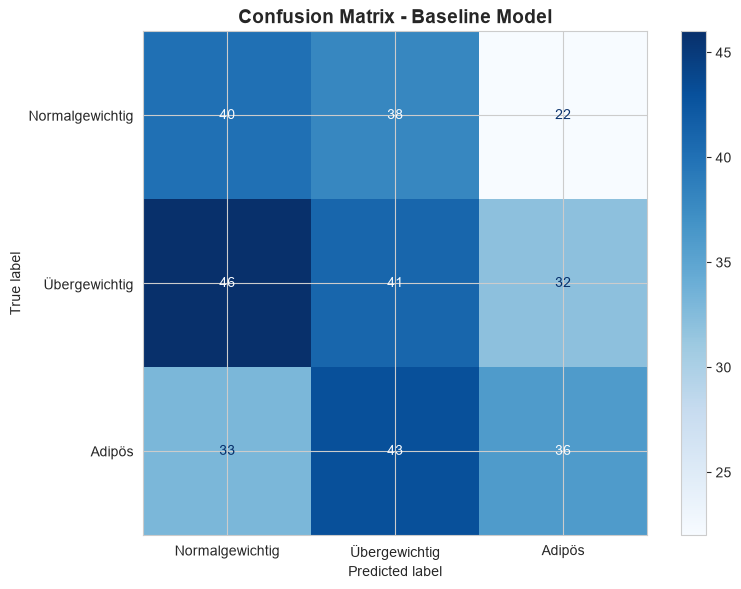

         Klasse  TP  FP  FN  TN
Normalgewichtig  40  79  60 152
  Übergewichtig  41  81  78 131
         Adipös  36  54  76 165


In [7]:
# Confusion Matrix berechnen
cm = confusion_matrix(y_test, y_pred_baseline, labels=[0, 1, 2])

# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Normalgewichtig', 'Übergewichtig', 'Adipös']
)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Baseline Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# One-vs-Rest Kennzahlen für alle Klassen
klassen_namen = ["Normalgewichtig", "Übergewichtig", "Adipös"]

ovr_ergebnisse = []
for klasse, name in enumerate(klassen_namen):
    tp = cm[klasse, klasse]
    fn = cm[klasse, :].sum() - tp
    fp = cm[:, klasse].sum() - tp
    tn = cm.sum() - tp - fn - fp
    ovr_ergebnisse.append({"Klasse": name, "TP": tp, "FP": fp, "FN": fn, "TN": tn})

ovr_df = pd.DataFrame(ovr_ergebnisse)
print(ovr_df.to_string(index=False))

### Aufgabe 3.1: Confusion Matrix interpretieren

**Fragen:**
1. Welche Art von Fehler (FP oder FN) ist in der Medizin gefährlicher?
2. Wie viele adipöse Patienten wurden vom Modell übersehen?
3. Wie viele gesunde Patienten wurden fälschlich als adipös/übergewichtig diagnostiziert?

**Diskutiert die Antworten im Notebook als Markdown-Zelle!**

1. FN ist gefährlicher! Bei FP würden vermutlich weitere Untersuchungen gemacht werden, bei denen dann der Fehler korrigiert werden würde. FN hätte zur Konsequenz, dass eben keine weiteren Untersuchungen gemacht werden würden und ein kranker Patient übersehen werden würde und auch nicht behandelt werden würde.
2. 76
3. 60

## Teil 4: Precision, Recall & F1-Score

Jetzt berechnen wir detailliertere Metriken.

In [8]:
# Classification Report
print(" Classification Report - Baseline Model:")
print("="*60)
print(classification_report(
    y_test, y_pred_baseline,
    labels=[0, 1, 2],
    target_names=["Normalgewichtig", "Übergewichtig", "Adipös"],
    digits=3
))

 Classification Report - Baseline Model:
                 precision    recall  f1-score   support

Normalgewichtig      0.336     0.400     0.365       100
  Übergewichtig      0.336     0.345     0.340       119
         Adipös      0.400     0.321     0.356       112

       accuracy                          0.353       331
      macro avg      0.357     0.355     0.354       331
   weighted avg      0.358     0.353     0.353       331



In [9]:
# Manuelle Berechnung zur Veranschaulichung (Klasse "Adipös" als positive class)
klasse = 2
tp = cm[klasse, klasse]
fn = cm[klasse, :].sum() - tp
fp = cm[:, klasse].sum() - tp

precision_adipoes = tp / (tp + fp)
recall_adipoes = tp / (tp + fn)
f1_adipoes = 2 * (precision_adipoes * recall_adipoes) / (precision_adipoes + recall_adipoes)

print(f"\n Metriken für Klasse 'Adipös' (positive class):")
print(f"Precision: {precision_adipoes:.3f} (Von allen als adipös vorhergesagten, wie viele sind wirklich adipös?)")
print(f"Recall:    {recall_adipoes:.3f} (Von allen adipösen Patienten, wie viele haben wir erkannt?)")
print(f"F1-Score:  {f1_adipoes:.3f} (Harmonisches Mittel von Precision und Recall)")


 Metriken für Klasse 'Adipös' (positive class):
Precision: 0.400 (Von allen als adipös vorhergesagten, wie viele sind wirklich adipös?)
Recall:    0.321 (Von allen adipösen Patienten, wie viele haben wir erkannt?)
F1-Score:  0.356 (Harmonisches Mittel von Precision und Recall)


### Aufgabe 4.1: Metriken verstehen

**Fragen:**
1. Was bedeutet eine hohe Precision in diesem medizinischen Kontext?
2. Was bedeutet ein hoher Recall in diesem medizinischen Kontext?
3. Welche Metrik ist wichtiger für die Herzkrankheits-Diagnose: Precision oder Recall? Warum?

**Eure Antwort hier als Markdown:**
1. Eine hohe Precision bedeutet z.B. für Normalgewichtige, dass viele als normalgewichtig eingeordnete Patienten auch normalgewichtig sind).
2. Ein hoher Recall von normalgewichtigen Patienten bedeutet, dass viele normalgewichtige Patienten auch als solche erkannt werden.
3. Recall ist wichtiger, da bei hohem Recall weniger kranke Patienten übersehen werden. Bei niedriger Precision werden auch Normalgewichtige als übergewichtig/adipös gelabelt, was aber durch weitere Tests dann korrigiert werden kann.

## Teil 5: ROC Curve & AUC

Die ROC Curve zeigt den Trade-off zwischen True Positive Rate und False Positive Rate.

Da es sich nicht um ein binäres Problem handelt, wird für jede Klasse eine Kurve angezeigt. Außerdem wird der macro-average genutzt, damit jede Klasse gleich gewichtet wird.

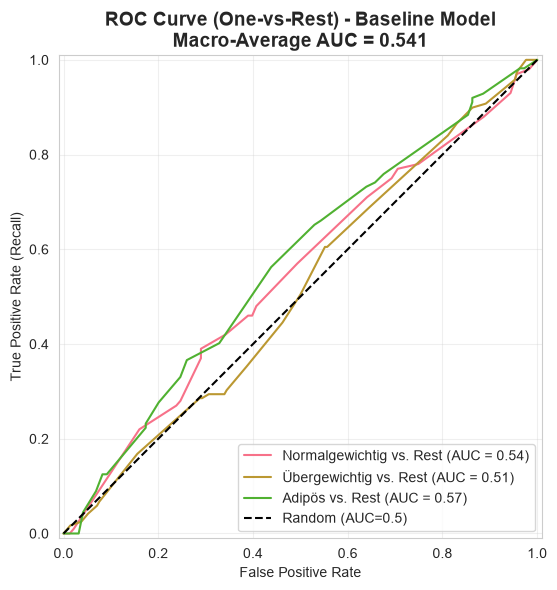


 ROC-AUC Score (Macro-Average, OvR): 0.541
Interpretation: Je näher an 1.0, desto besser trennt das Modell die drei Klassen!


In [10]:
# Wahrscheinlichkeiten für alle Klassen
y_proba_baseline = baseline_model.predict_proba(X_test)  # shape (n_samples, 3)

# ROC-AUC (Macro-Average über alle Klassen, One-vs-Rest)
roc_auc_baseline = roc_auc_score(y_test, y_proba_baseline, multi_class="ovr", average="macro")

# One-vs-Rest ROC Curves für jede Klasse plotten
klassen_namen = ["Normalgewichtig", "Übergewichtig", "Adipös"]
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(10, 6))
for i, name in enumerate(klassen_namen):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_proba_baseline[:, i],
        name=f"{name} vs. Rest",
        ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")
plt.title(f"ROC Curve (One-vs-Rest) - Baseline Model\nMacro-Average AUC = {roc_auc_baseline:.3f}",
         fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n ROC-AUC Score (Macro-Average, OvR): {roc_auc_baseline:.3f}")
print(f"Interpretation: Je näher an 1.0, desto besser trennt das Modell die drei Klassen!")

Hier zeigt sich wie schon in dem ersten Teil zu ML eine sehr schlechte Performance des Modells. Für alle drei Klassen ist der ROC-AUC Score nahe 0,5, was Raten entspricht.

## Teil 6: Cross-Validation - Robuste Evaluation

Ein einzelner Train/Test Split kann vom Zufall abhängen. Cross-Validation gibt uns eine robustere Schätzung.

Wegen der drei Klassen habe ich die Metriken entsprechend angepasst (macro bzw. ovr).

In [11]:
# 5-Fold Cross-Validation für verschiedene Metriken
metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_ovr"]
print(" 5-Fold Cross-Validation Results (Baseline Model):")
print("="*70)
cv_results = {}
for metric in metrics:
    scores = cross_val_score(
        baseline_model, X, y, cv=5, scoring=metric
    )
    cv_results[metric] = scores
    print(f"{metric.upper():16s}: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"                 Individual scores: {[f'{s:.3f}' for s in scores]}")

 5-Fold Cross-Validation Results (Baseline Model):
ACCURACY        : 0.374 (+/- 0.027)
                 Individual scores: ['0.408', '0.399', '0.338', '0.376', '0.348']
PRECISION_MACRO : 0.370 (+/- 0.037)
                 Individual scores: ['0.409', '0.408', '0.318', '0.378', '0.339']
RECALL_MACRO    : 0.373 (+/- 0.031)
                 Individual scores: ['0.414', '0.400', '0.330', '0.372', '0.351']
F1_MACRO        : 0.358 (+/- 0.033)
                 Individual scores: ['0.405', '0.375', '0.310', '0.366', '0.335']
ROC_AUC_OVR     : 0.554 (+/- 0.024)
                 Individual scores: ['0.585', '0.570', '0.520', '0.559', '0.535']


Da drei Klassen unterschieden werden, liegt die Random Baseline für Accuracy, Precision, Recall und F1 nicht mehr bei 0,5, sondern bei 0,33. Für ROC-AUC bleibt es bei den 0,5, für den folgenden Graph habe ich mich aber für 0,33 entschieden.

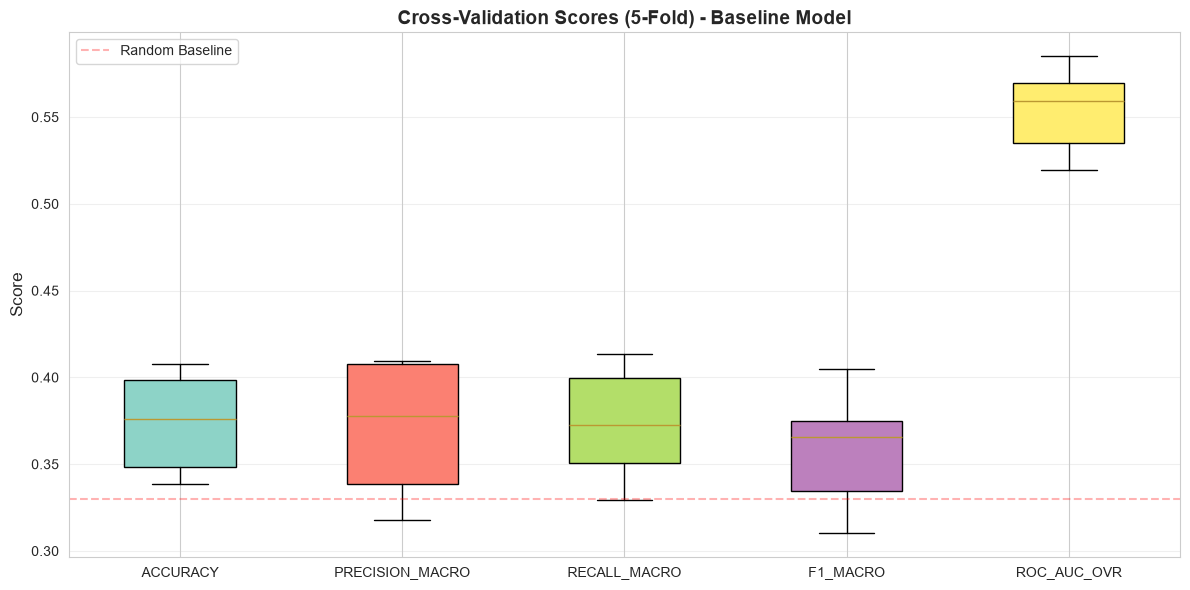

In [12]:
# Visualisierung der CV Scores
fig, ax = plt.subplots(figsize=(12, 6))

positions = np.arange(len(metrics))
bp = ax.boxplot([cv_results[m] for m in metrics], 
                 positions=positions,
                 tick_labels=[m.upper() for m in metrics],
                 patch_artist=True,
                 notch=False) # um Kerben zu vermeiden

# Farben
colors = plt.cm.Set3(np.linspace(0, 1, len(metrics)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Cross-Validation Scores (5-Fold) - Baseline Model', 
            fontsize=14, fontweight='bold')
ax.axhline(y=0.33, color='r', linestyle='--', alpha=0.3, label='Random Baseline')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
plt.tight_layout()
plt.show()

### Aufgabe 6.1: CV Interpretation

**Fragen:**
1. Warum ist Cross-Validation robuster als ein einzelner Train/Test Split?
2. Welche Metrik hat die höchste Varianz (Standardabweichung)?
3. Ist das Modell stabil oder variiert die Performance stark?

**Eure Antwort hier:**
1. Ein einzelner Train/Test Split ist zufallsabhängig, bei der Cross-Validation wird der Zufallseffekt vermindert.
2. Precision
3. Die Standardabweichung liegt für alle Performance Maße zwischen 0.024 und 0.037. Das spricht für eine recht stabile Performance.

## Teil 7: Feature Engineering

Bessere Features = Bessere Modelle! Erstellen wir neue Features.

In [13]:
# Original Features kopieren
X_engineered = X.copy()

# Prüfe welche Spalten verfügbar sind
available_cols = X.columns.tolist()
print(f"Verfügbare Features: {available_cols}\n")

# ============================================================
# 1. Interaktions-Features
# ============================================================
print("1. Interaktions-Features")
print("-" * 40)

if "sleep_avg" in available_cols and "sedentary_act_min" in available_cols:
    X_engineered["sleep_sedentary_interaction"] = X["sleep_avg"] * X["sedentary_act_min"]
    print("✅ Created: sleep_sedentary_interaction")

if "alcohol" in available_cols and "sedentary_act_min" in available_cols:
    X_engineered["alcohol_sedentary_interaction"] = X["alcohol"] * X["sedentary_act_min"]
    print("✅ Created: alcohol_sedentary_interaction")

# ============================================================
# 2. Ratios
# ============================================================
print("\n2. Ratios")
print("-" * 40)

if "activity_level" in available_cols and "sedentary_act_min" in available_cols:
    X_engineered["activity_sedentary_ratio"] = X["activity_level"] / (X["sedentary_act_min"] + 1)
    print("✅ Created: activity_sedentary_ratio")

if "sugar" in available_cols and "fiber" in available_cols:
    X_engineered["sugar_fiber_ratio"] = X["sugar"] / (X["fiber"] + 1)
    print("✅ Created: sugar_fiber_ratio")

if "protein" in available_cols and "kcal" in available_cols:
    X_engineered["protein_per_kcal"] = X["protein"] / (X["kcal"] + 1)
    print("✅ Created: protein_per_kcal")

# ============================================================
# 3. Binning - Alter in Gruppen
# ============================================================
print("\n3. Binning - Alter in Gruppen")
print("-" * 40)

if "age" in available_cols:
    X_engineered["age_group_young"] = (X["age"] < 35).astype(int)
    X_engineered["age_group_middle"] = ((X["age"] >= 35) & (X["age"] < 60)).astype(int)
    X_engineered["age_group_old"] = (X["age"] >= 60).astype(int)
    print("✅ Created: age_group features (young: <35, middle: 35-59, old: 60+)")
    print(X_engineered[["age_group_young", "age_group_middle", "age_group_old"]].sum())

# ============================================================
# 4. Sozioökonomischer Kombi-Score
# ============================================================
print("\n4. Sozioökonomischer Kombi-Score")
print("-" * 40)

if "income" in available_cols and "education_lvl" in available_cols:
    X_engineered["ses_score"] = X["income"] + X["education_lvl"]
    print("✅ Created: ses_score")

# ============================================================
# 5. Lifestyle-Risiko-Score (kombiniert mehrere Features)
# ============================================================
print("\n5. Lifestyle-Risiko-Score")
print("-" * 40)

risk_features = ["sedentary_act_min", "activity_level", "smoke_status", "alcohol"]
if all(feat in available_cols for feat in risk_features):
    X_engineered["lifestyle_risk_score"] = (
        (X["sedentary_act_min"] > X["sedentary_act_min"].median()).astype(int) +
        (X["activity_level"] < X["activity_level"].median()).astype(int) +
        X["smoke_status"] +
        (X["alcohol"] > X["alcohol"].median()).astype(int)
    )
    print("✅ Created: lifestyle_risk_score")
else:
    print(f" Cannot create lifestyle_risk_score, missing features: {[f for f in risk_features if f not in available_cols]}")

# ============================================================
# Feature Summary
# ============================================================
print(f"\n Feature Summary:")
print(f"Original Features: {X.shape[1]}")
print(f"Neue Features erstellt: {X_engineered.shape[1] - X.shape[1]}")
print(f"Gesamt Features: {X_engineered.shape[1]}")

print(f"\n Alle neuen Features:")
new_features = [col for col in X_engineered.columns if col not in X.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")

Verfügbare Features: ['gender', 'age', 'education_lvl', 'income', 'kcal', 'protein', 'carbs', 'sugar', 'fiber', 'fat', 'alcohol', 'sedentary_act_min', 'smoke_status', 'activity_level', 'sleep_avg']

1. Interaktions-Features
----------------------------------------
✅ Created: sleep_sedentary_interaction
✅ Created: alcohol_sedentary_interaction

2. Ratios
----------------------------------------
✅ Created: activity_sedentary_ratio
✅ Created: sugar_fiber_ratio
✅ Created: protein_per_kcal

3. Binning - Alter in Gruppen
----------------------------------------
✅ Created: age_group features (young: <35, middle: 35-59, old: 60+)
age_group_young     425
age_group_middle    638
age_group_old       590
dtype: int64

4. Sozioökonomischer Kombi-Score
----------------------------------------
✅ Created: ses_score

5. Lifestyle-Risiko-Score
----------------------------------------
✅ Created: lifestyle_risk_score

 Feature Summary:
Original Features: 15
Neue Features erstellt: 10
Gesamt Features: 25



In [14]:
# Train/Test Split mit neuen Features
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42, stratify=y
)

# Modell mit neuen Features trainieren
model_engineered = DecisionTreeClassifier(max_depth=5, random_state=42)
model_engineered.fit(X_train_eng, y_train_eng)

# Evaluation
y_pred_eng = model_engineered.predict(X_test_eng)

print(f"\n Vergleich: Original vs. Feature Engineering")
print("="*60)
print(f"Baseline Accuracy:   {baseline_model.score(X_test, y_test):.3f}")
print(f"Engineered Accuracy: {model_engineered.score(X_test_eng, y_test_eng):.3f}")

# F1-Score Vergleich (macro-average wegen 3 Klassen)
f1_baseline = f1_score(y_test, y_pred_baseline, average="macro")
f1_eng = f1_score(y_test_eng, y_pred_eng, average="macro")

print(f"\nBaseline F1-Score (macro):   {f1_baseline:.3f}")
print(f"Engineered F1-Score (macro): {f1_eng:.3f}")
print(f"\n{'✅ Verbesserung!' if f1_eng > f1_baseline else '❌ Verschlechterung'}")


 Vergleich: Original vs. Feature Engineering
Baseline Accuracy:   0.353
Engineered Accuracy: 0.329

Baseline F1-Score (macro):   0.354
Engineered F1-Score (macro): 0.327

❌ Verschlechterung


## Teil 8: Hyperparameter Tuning mit GridSearchCV

Finden wir die optimalen Hyperparameter für unser Modell! Wir müssen wieder anstatt 'f1' 'fi1_macro' nutzen, da es keine binäre Betrachtung mehr ist.

In [15]:
# Parameter-Grid für Decision Tree
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV mit F1-Score als Metrik (wichtig für unbalancierte Daten!)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("🔍 Starte GridSearchCV...")
print(f"Anzahl Kombinationen: {len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['criterion'])}")
print(f"Mit 5-Fold CV: {5 * 5 * 4 * 4 * 2} Modelle werden trainiert!\n")

grid_search.fit(X_train_eng, y_train_eng)

🔍 Starte GridSearchCV...
Anzahl Kombinationen: 160
Mit 5-Fold CV: 800 Modelle werden trainiert!

Fitting 5 folds for each of 160 candidates, totalling 800 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_a

In [16]:
# Beste Parameter
print(" Beste Parameter:")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"{param:20s}: {value}")

print(f"\n Beste CV F1-Score: {grid_search.best_score_:.3f}")

 Beste Parameter:
criterion           : gini
max_depth           : 3
min_samples_leaf    : 1
min_samples_split   : 2

 Beste CV F1-Score: 0.413


In [17]:
# Top 10 Konfigurationen
results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']] \
    .sort_values('rank_test_score') \
    .head(10)

print("\n Top 10 Parameter-Kombinationen:")
print("="*80)
display(top_results)


 Top 10 Parameter-Kombinationen:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
1,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
2,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
3,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
4,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
5,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
6,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
7,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
8,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1
9,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.413054,0.01569,1


In [18]:
# Bestes Modell evaluieren auf Test-Set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_eng)

print("\n Vergleich: Baseline vs. GridSearch-Optimiert")
print("="*70)
print(f"Baseline (max_depth=5):")
print(f"  Test Accuracy:  {baseline_model.score(X_test, y_test):.3f}")
print(f"  Test F1-Score:  {f1_score(y_test, y_pred_baseline, average='macro'):.3f}")

print(f"\nOptimiert (GridSearch):")
print(f"  Test Accuracy:  {best_model.score(X_test_eng, y_test_eng):.3f}")
print(f"  Test F1-Score:  {f1_score(y_test_eng, y_pred_best, average='macro'):.3f}")


 Vergleich: Baseline vs. GridSearch-Optimiert
Baseline (max_depth=5):
  Test Accuracy:  0.353
  Test F1-Score:  0.354

Optimiert (GridSearch):
  Test Accuracy:  0.350
  Test F1-Score:  0.350


Auf den Testdaten haben sich Accuracy und F1-Score im Vergleich zur Baseline sogar leicht verschlechtert um 0.003 bzw. 0.004.

### Aufgabe 8.1: Random Forest Tuning

Probiert GridSearchCV mit **Random Forest** anstatt Decision Tree:

```python
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
```

**Code hier:**

In [19]:
# Baseline: Random Forest ohne Tuning (zum Vergleich mit GridSearch-Version)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_eng, y_train_eng)

# Predictions
y_pred_rf_baseline = rf_baseline.predict(X_test_eng)

# Accuracy & F1 (macro, wegen 3 Klassen)
rf_baseline_accuracy = rf_baseline.score(X_test_eng, y_test_eng)
rf_baseline_f1 = f1_score(y_test_eng, y_pred_rf_baseline, average="macro")

print(f"Random Forest Baseline Accuracy: {rf_baseline_accuracy:.3f}")
print(f"Random Forest Baseline F1-Score (macro): {rf_baseline_f1:.3f}")

Random Forest Baseline Accuracy: 0.414
Random Forest Baseline F1-Score (macro): 0.410


In [20]:
# Parameter-Grid für Random Forest
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

# GridSearchCV mit F1-Score (macro) als Metrik (wichtig für unbalancierte Daten!)
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("🔍 Starte GridSearchCV (Random Forest)...")
print(f"Anzahl Kombinationen: {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split'])}")
print(f"Mit 5-Fold CV: {3 * 3 * 3 * 5} Modelle werden trainiert!\n")

grid_search_rf.fit(X_train_eng, y_train_eng)

# Beste Parameter
print("\nBeste Parameter (Random Forest):")
print("="*60)
for param, value in grid_search_rf.best_params_.items():
    print(f"{param:20s}: {value}")

print(f"\nBeste CV F1-Score (macro): {grid_search_rf.best_score_:.3f}")

🔍 Starte GridSearchCV (Random Forest)...
Anzahl Kombinationen: 27
Mit 5-Fold CV: 135 Modelle werden trainiert!

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Beste Parameter (Random Forest):
max_depth           : 5
min_samples_split   : 2
n_estimators        : 100

Beste CV F1-Score (macro): 0.431


In [21]:
# Bestes Random Forest Modell evaluieren auf Test-Set
best_model_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_model_rf.predict(X_test_eng)

print("\nVergleich: RF Baseline vs. RF GridSearch-Optimiert")
print("="*70)
print(f"RF Baseline:")
print(f"  Test Accuracy:  {rf_baseline_accuracy:.3f}")
print(f"  Test F1-Score (macro):  {rf_baseline_f1:.3f}")

print(f"\nRF Optimiert (GridSearch):")
print(f"  Test Accuracy:  {best_model_rf.score(X_test_eng, y_test_eng):.3f}")
print(f"  Test F1-Score (macro):  {f1_score(y_test_eng, y_pred_best_rf, average='macro'):.3f}")

print(f"\nZum Vergleich - Decision Tree GridSearch-Optimiert:")
print(f"  Test F1-Score (macro):  {f1_score(y_test_eng, y_pred_best, average='macro'):.3f}")


Vergleich: RF Baseline vs. RF GridSearch-Optimiert
RF Baseline:
  Test Accuracy:  0.414
  Test F1-Score (macro):  0.410

RF Optimiert (GridSearch):
  Test Accuracy:  0.441
  Test F1-Score (macro):  0.429

Zum Vergleich - Decision Tree GridSearch-Optimiert:
  Test F1-Score (macro):  0.350


Durch die GridSearch konnte die Test Accuracy um 0.027 und der F1-score um 0.019 im Vergleich zur Baseline verbessert werden. Sowohl Baseline, als auch optimierter Random Forest sind besser als der Decision Tree. Trotzdem ist Performance noch immer nur leicht über der Zufalls-Baseline.

## Teil 9: Pipeline - Alles zusammen

Erstellen wir eine elegante Pipeline die alle Schritte kombiniert.
Da der Random Forest besser performt hat, habe ich mich für die Pipeline dafür entschieden.

In [22]:
# Pipeline erstellen
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(f_classif, k=10)),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Parameter-Grid für Pipeline
param_grid_pipeline = {
    "selector__k": [5, 10, 15, 20],
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5, 10]
}

# GridSearch auf Pipeline
grid_search_pipeline = GridSearchCV(
    pipeline,
    param_grid_pipeline,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("🔧 Starte Pipeline GridSearch (Random Forest)...\n")
grid_search_pipeline.fit(X_train_eng, y_train_eng)

🔧 Starte Pipeline GridSearch (Random Forest)...

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [50, 100, ...], 'selector__k': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metric

In [23]:
# Beste Pipeline-Parameter
print(" Beste Pipeline-Parameter:")
print("="*60)
for param, value in grid_search_pipeline.best_params_.items():
    print(f"{param:35s}: {value}")

print(f"\n Beste CV F1-Score (macro): {grid_search_pipeline.best_score_:.3f}")

# Welche Features wurden ausgewählt?
best_pipeline = grid_search_pipeline.best_estimator_
selector = best_pipeline.named_steps['selector']
selected_features = X_train_eng.columns[selector.get_support()]

print(f"\n Ausgewählte Features (Top {len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

 Beste Pipeline-Parameter:
classifier__max_depth              : 5
classifier__min_samples_split      : 2
classifier__n_estimators           : 200
selector__k                        : 20

 Beste CV F1-Score (macro): 0.438

 Ausgewählte Features (Top 20):
  1. gender
  2. education_lvl
  3. income
  4. kcal
  5. carbs
  6. sugar
  7. fiber
  8. alcohol
  9. sedentary_act_min
  10. smoke_status
  11. activity_level
  12. sleep_avg
  13. sleep_sedentary_interaction
  14. activity_sedentary_ratio
  15. sugar_fiber_ratio
  16. age_group_young
  17. age_group_middle
  18. age_group_old
  19. ses_score
  20. lifestyle_risk_score



 FINALER MODELL-VERGLEICH


,Model,Accuracy,Precision (macro),Recall (macro),F1-Score (macro),"ROC-AUC (macro, ovr)"
0,DT Baseline (Woche 9),0.353,0.357,0.355,0.354,0.541
1,DT Feature Engineering,0.329,0.331,0.327,0.327,0.540
2,DT GridSearch Optimiert,0.350,0.351,0.350,0.350,0.541
3,RF Baseline,0.414,0.410,0.411,0.410,0.576
4,RF GridSearch Optimiert,0.441,0.439,0.433,0.429,0.599
5,"Pipeline (RF, Best)",0.450,0.449,0.444,0.442,0.599


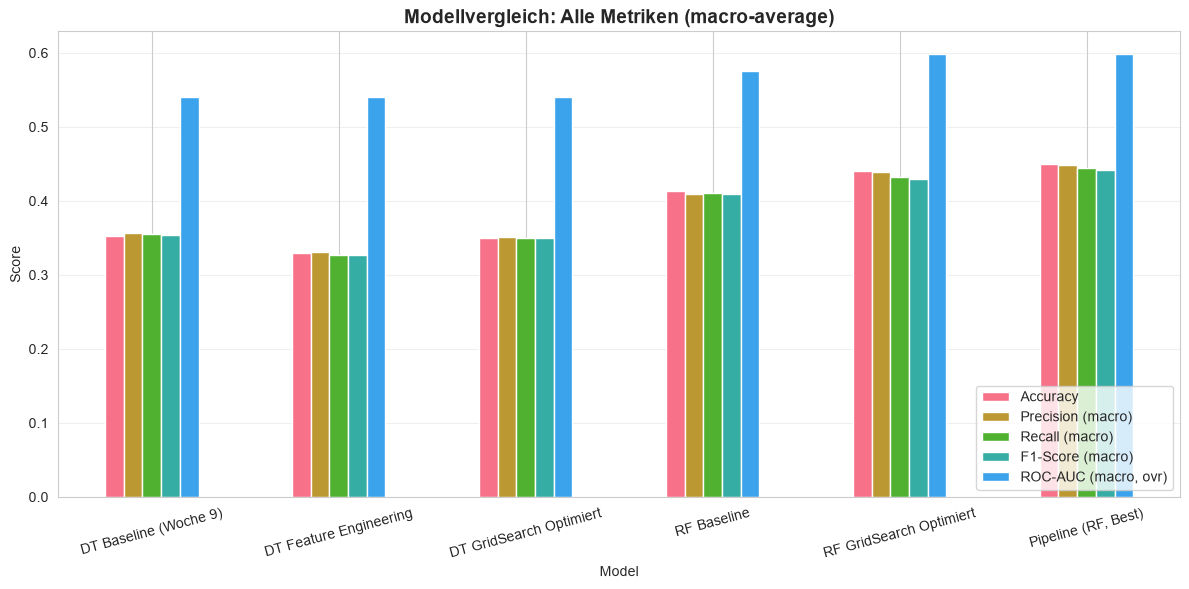

In [24]:
# Finale Evaluation auf Test-Set
y_pred_pipeline = best_pipeline.predict(X_test_eng)

print("\n" + "="*70)
print(" FINALER MODELL-VERGLEICH")
print("="*70)

models_comparison = {
    "DT Baseline (Woche 9)": (baseline_model, X_test, y_test, y_pred_baseline),
    "DT Feature Engineering": (model_engineered, X_test_eng, y_test_eng, y_pred_eng),
    "DT GridSearch Optimiert": (best_model, X_test_eng, y_test_eng, y_pred_best),
    "RF Baseline": (rf_baseline, X_test_eng, y_test_eng, y_pred_rf_baseline),
    "RF GridSearch Optimiert": (best_model_rf, X_test_eng, y_test_eng, y_pred_best_rf),
    "Pipeline (RF, Best)": (best_pipeline, X_test_eng, y_test_eng, y_pred_pipeline)
}

comparison_results = []
for name, (model, X_t, y_t, y_p) in models_comparison.items():
    y_proba_t = model.predict_proba(X_t)
    roc_auc_t = roc_auc_score(y_t, y_proba_t, multi_class="ovr", average="macro")
    
    comparison_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_t, y_p),
        'Precision (macro)': precision_score(y_t, y_p, average='macro'),
        'Recall (macro)': recall_score(y_t, y_p, average='macro'),
        'F1-Score (macro)': f1_score(y_t, y_p, average='macro'),
        'ROC-AUC (macro, ovr)': roc_auc_t
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.round(3)
display(comparison_df)

# Visualisierung
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.set_index('Model')[['Accuracy', 'Precision (macro)', 'Recall (macro)',
                                  'F1-Score (macro)', 'ROC-AUC (macro, ovr)']].plot(
    kind='bar', ax=ax, rot=15
)
ax.set_ylabel('Score')
ax.set_title('Modellvergleich: Alle Metriken (macro-average)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Teil 10: Confusion Matrix & ROC für bestes Modell

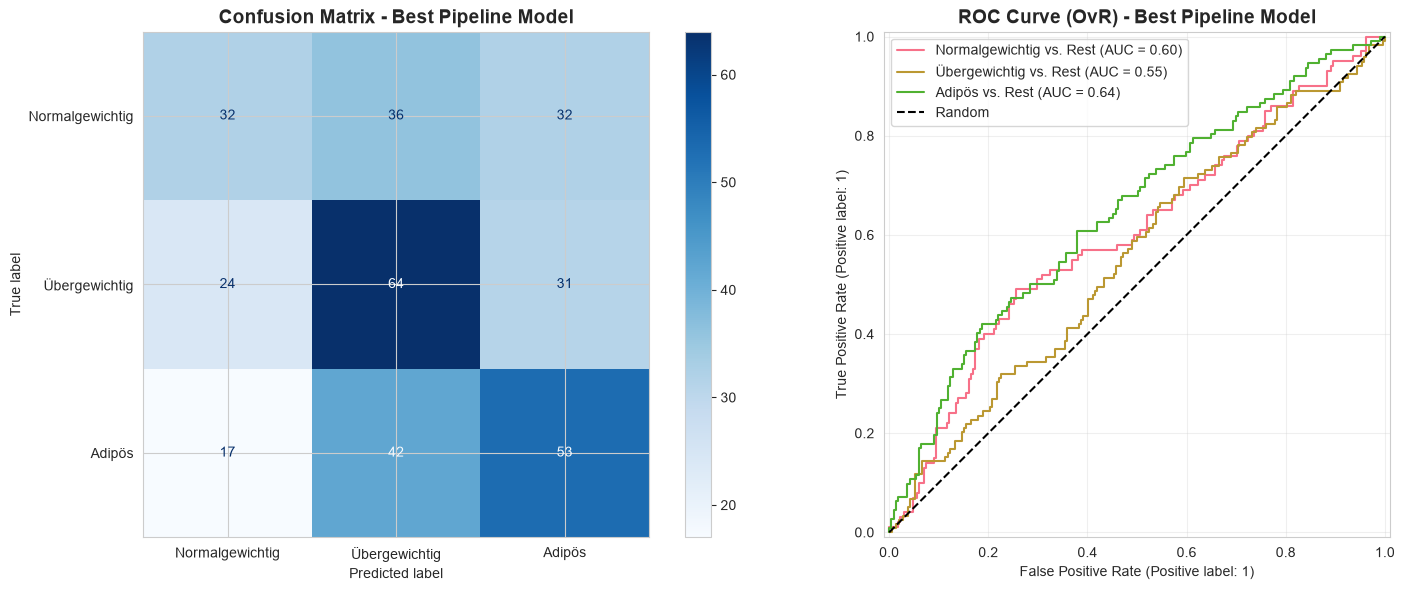


ROC-AUC Score (Macro-Average, OvR) - Pipeline Model: 0.599


In [25]:
# Confusion Matrix für bestes Modell
cm_best = confusion_matrix(y_test_eng, y_pred_pipeline, labels=[0, 1, 2])
klassen_namen = ["Normalgewichtig", "Übergewichtig", "Adipös"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=klassen_namen
)
disp.plot(cmap='Blues', ax=ax1, values_format='d')
ax1.set_title('Confusion Matrix - Best Pipeline Model', fontsize=14, fontweight='bold')

# ROC Curve
y_proba_pipeline = best_pipeline.predict_proba(X_test_eng)
y_test_eng_binarized = label_binarize(y_test_eng, classes=[0, 1, 2])
for i, name in enumerate(klassen_namen):
    RocCurveDisplay.from_predictions(
        y_test_eng_binarized[:, i],
        y_proba_pipeline[:, i],
        name=f"{name} vs. Rest",
        ax=ax2
    )
ax2.plot([0, 1], [0, 1], "k--", label="Random")
ax2.set_title("ROC Curve (OvR) - Best Pipeline Model", fontsize=14, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
roc_auc_pipeline = roc_auc_score(y_test_eng, y_proba_pipeline, multi_class="ovr", average="macro")
print(f"\nROC-AUC Score (Macro-Average, OvR) - Pipeline Model: {roc_auc_pipeline:.3f}")

In [26]:
# Detaillierter Classification Report
print("\nFINALER CLASSIFICATION REPORT (Best Pipeline Model):")
print("="*70)
print(classification_report(
    y_test_eng, y_pred_pipeline,
    labels=[0, 1, 2],
    target_names=["Normalgewichtig", "Übergewichtig", "Adipös"],
    digits=3
))


FINALER CLASSIFICATION REPORT (Best Pipeline Model):
                 precision    recall  f1-score   support

Normalgewichtig      0.438     0.320     0.370       100
  Übergewichtig      0.451     0.538     0.490       119
         Adipös      0.457     0.473     0.465       112

       accuracy                          0.450       331
      macro avg      0.449     0.444     0.442       331
   weighted avg      0.449     0.450     0.445       331



Zusammenfassed kann man sagen, dass die Pipeline die Performance im Vergleich zum Baseline Random Forest leicht verbessert hat. Die Accuracy ist von 0.414 auf 0.450 gestiegen, die Precision von 0.410 auf 0.449, der Recall von 0.411 auf 0.444, der F1 Score von 0.410 auf 0.442 und die ROC-AUC von 0.576 auf 0.599. Trotzdem ist die Performance insgesamt schwach, was sich auch in der ROC Curve wiederspiegelt. Die beste AUC zeigt sich für Adipöse, die schlechteste für Übergewichtige. Durchschnittlich liegt sich bei 0.599. Übergewicht kann scheinbar schlecht von den anderen beiden Klassen getrennt werden, es gibt eine Verzerrung zur Mitte.
Von den beiden getesteten Modellen hat der Random Forest durchweg die besseren Performance Parameter. Auch in der Analyse zu ML1 von der vorherigen Woche war der Random Forest anhand der Accuracy das beste Modell.

## Speichern für die Streamlit App

In [27]:
# Finale Pipeline speichern
joblib.dump(best_pipeline, "obesity_model.pkl")

# Trainings-Mediane sichern (werden für lifestyle_risk_score in der App gebraucht)
training_medians = {
    "sedentary_act_min": X_train_eng["sedentary_act_min"].median(),
    "activity_level": X_train_eng["activity_level"].median(),
    "alcohol": X_train_eng["alcohol"].median()
}
joblib.dump(training_medians, "training_medians.pkl")

['training_medians.pkl']

## Bonus: Confusion Matrix Heatmap mit Seaborn

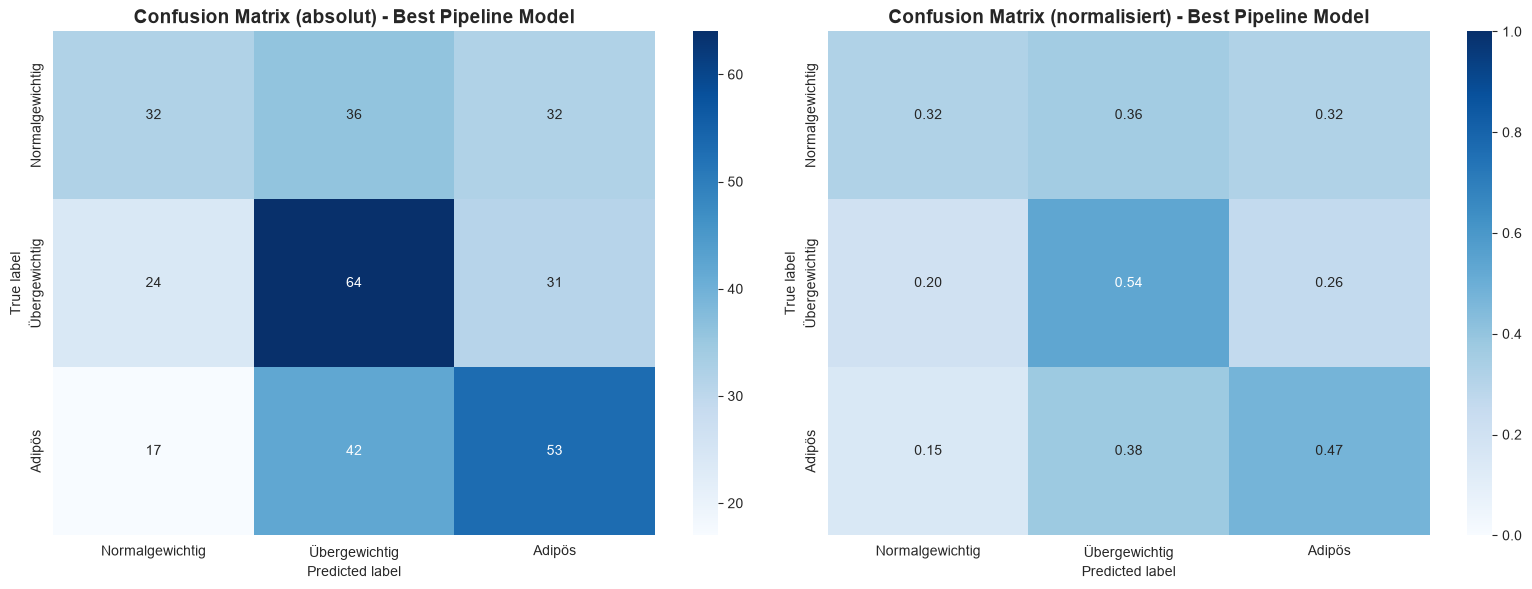

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absolute Zahlen
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=klassen_namen,
    yticklabels=klassen_namen,
    cbar=True,
    ax=ax1
)
ax1.set_title("Confusion Matrix (absolut) - Best Pipeline Model", fontsize=14, fontweight="bold")
ax1.set_xlabel("Predicted label")
ax1.set_ylabel("True label")

# Normalisiert (zeilenweise, zeigt Recall pro Klasse)
cm_normalized = cm_best.astype("float") / cm_best.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=klassen_namen,
    yticklabels=klassen_namen,
    vmin=0, vmax=1,
    cbar=True,
    ax=ax2
)
ax2.set_title("Confusion Matrix (normalisiert) - Best Pipeline Model", fontsize=14, fontweight="bold")
ax2.set_xlabel("Predicted label")
ax2.set_ylabel("True label")

plt.tight_layout()
plt.show()

## Zusammenfassung & Learnings

### ✅ Was haben wir gelernt?

1. **Evaluation Metriken:** Accuracy allein reicht nicht! Precision, Recall, F1-Score geben detailliertere Einblicke
2. **Confusion Matrix:** Verstehen welche Fehler das Modell macht (FP vs. FN)
3. **Cross-Validation:** Robustere Evaluation durch mehrfache Splits
4. **Hyperparameter Tuning:** GridSearchCV findet optimale Parameter automatisch
5. **Feature Engineering:** Neue Features können Modell-Performance deutlich verbessern
6. **Pipeline:** Eleganter und wiederverwendbarer Workflow


## Für die App: Testung der Grenzwerte

In [29]:
# Nur die Features, die in der App als Eingabefelder vorkommen
input_features = [
    "age", "income", "kcal", "protein", "carbs", "sugar",
    "fiber", "fat", "sedentary_act_min", "sleep_avg"
]

df[input_features].describe()

,age,income,kcal,protein,carbs,sugar,fiber,fat,sedentary_act_min,sleep_avg
count,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000,1653.00000
mean,49.277072,3.585384,2092.766485,81.235511,228.471470,93.133358,17.820024,88.429873,369.322444,7.79141
std,16.914740,1.503596,905.406869,41.802472,110.071125,61.679352,10.956369,46.623737,198.662966,1.25316
min,20.000000,0.020000,249.000000,5.890000,3.490000,0.750000,0.200000,3.250000,30.000000,2.00000
25%,34.000000,2.330000,1469.000000,53.500000,151.490000,51.230000,10.600000,56.520000,240.000000,7.10000
50%,50.000000,4.060000,1959.000000,74.100000,210.200000,80.290000,15.700000,80.950000,360.000000,8.00000
75%,64.000000,5.000000,2543.000000,100.100000,284.050000,121.870000,22.600000,110.300000,480.000000,8.50000
max,80.000000,5.000000,10446.000000,459.150000,1210.930000,509.710000,117.300000,505.620000,1320.000000,13.70000
